In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from warnings import filterwarnings
filterwarnings("ignore")

In [3]:
data = pd.read_csv("Bank_loans.csv")
df = data.copy()
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [4]:
df.shape

(100514, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100514 entries, 0 to 100513
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  object 
 1   Customer ID                   100000 non-null  object 
 2   Loan Status                   100000 non-null  object 
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  object 
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   object 
 8   Home Ownership                100000 non-null  object 
 9   Purpose                       100000 non-null  object 
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null

In [6]:
df.isnull().sum()

Loan ID                           514
Customer ID                       514
Loan Status                       514
Current Loan Amount               514
Term                              514
Credit Score                    19668
Annual Income                   19668
Years in current job             4736
Home Ownership                    514
Purpose                           514
Monthly Debt                      514
Years of Credit History           514
Months since last delinquent    53655
Number of Open Accounts           514
Number of Credit Problems         514
Current Credit Balance            514
Maximum Open Credit               516
Bankruptcies                      718
Tax Liens                         524
dtype: int64

In [7]:
df[df["Loan ID"].isna()]

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# drop useless data from dataset

df = df[~df["Loan ID"].isna()]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  object 
 1   Customer ID                   100000 non-null  object 
 2   Loan Status                   100000 non-null  object 
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  object 
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   object 
 8   Home Ownership                100000 non-null  object 
 9   Purpose                       100000 non-null  object 
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null 

In [10]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,100000.0,1.176045e+07,3.178394e+07,10802.0,179652.0000,312246.0,5.249420e+05,1.000000e+08
Credit Score,80846.0,1.076456e+03,1.475404e+03,585.0,705.0000,724.0,7.410000e+02,7.510000e+03
Annual Income,80846.0,1.378277e+06,1.081360e+06,76627.0,848844.0000,1174162.0,1.650663e+06,1.655574e+08
Monthly Debt,100000.0,1.847241e+04,1.217499e+04,0.0,10214.1625,16220.3,2.401206e+04,4.358433e+05
Years of Credit History,100000.0,1.819914e+01,7.015324e+00,3.6,13.5000,16.9,2.170000e+01,7.050000e+01
Months since last delinquent,46859.0,3.490132e+01,2.199783e+01,0.0,16.0000,32.0,5.100000e+01,1.760000e+02
Number of Open Accounts,100000.0,1.112853e+01,5.009870e+00,0.0,8.0000,10.0,1.400000e+01,7.600000e+01
Number of Credit Problems,100000.0,1.683100e-01,4.827050e-01,0.0,0.0000,0.0,0.000000e+00,1.500000e+01
Current Credit Balance,100000.0,2.946374e+05,3.761709e+05,0.0,112670.0000,209817.0,3.679588e+05,3.287897e+07
Maximum Open Credit,99998.0,7.607984e+05,8.384503e+06,0.0,273438.0000,467874.0,7.829580e+05,1.539738e+09


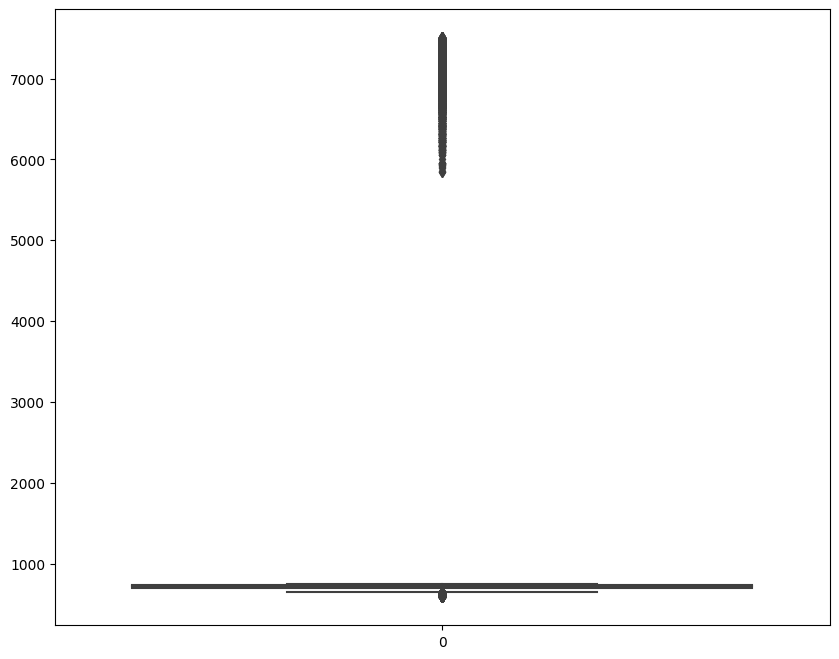

In [12]:
plt.figure(figsize = (10,8))
sns.boxplot(df["Credit Score"]);

In [13]:
df[df["Credit Score"] > 5000]

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
5,89d8cb0c-e5c2-4f54-b056-48a645c543dd,4ffe99d3-7f2a-44db-afc1-40943f1f9750,Charged Off,206602.0,Short Term,7290.0,896857.0,10+ years,Home Mortgage,Debt Consolidation,16367.74,17.3,NaN,6.0,0.0,215308.0,272448.0,0.0,0.0
43,0c84b81a-e5a9-4a92-8dc8-fb179add03a4,628b0914-b1d7-4028-b590-b50f5da53d06,Charged Off,288948.0,Short Term,7120.0,537472.0,10+ years,Rent,Debt Consolidation,5777.90,14.8,NaN,4.0,0.0,132468.0,164406.0,0.0,0.0
51,0daecc08-0354-4753-b282-52124b2420df,2884d362-391a-4941-af69-c825cae18002,Charged Off,219692.0,Long Term,6610.0,527839.0,10+ years,Rent,Debt Consolidation,14207.63,17.0,48.0,9.0,0.0,254277.0,379918.0,0.0,0.0
56,a5ada080-a058-4ad2-8953-002b7ec1ae31,9966e08c-04a6-41ab-86d0-e4062c64bd41,Charged Off,78012.0,Short Term,7380.0,728726.0,4 years,Rent,major_purchase,10135.36,11.4,NaN,8.0,0.0,104633.0,199936.0,0.0,0.0
65,1704367e-1d71-4551-8d33-49aa15cab4b1,88f97adf-070a-47b1-9657-38276eef7d19,Charged Off,523908.0,Long Term,7370.0,1028774.0,6 years,Home Mortgage,Debt Consolidation,22632.99,19.3,NaN,5.0,0.0,474658.0,742720.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99851,5eee6c31-62d4-400c-a81f-37bd373db926,039ee8d2-3321-4683-9592-cb1a360c34e2,Charged Off,198572.0,Short Term,7420.0,526205.0,2 years,Rent,Debt Consolidation,9910.02,16.5,NaN,8.0,0.0,296704.0,433224.0,0.0,0.0
99872,ce1f8220-7eba-4ec1-8bef-ca28f4916801,3e108ac9-9b7c-44a9-9289-e389cf3085b1,Charged Off,110924.0,Short Term,7070.0,804631.0,4 years,Rent,Debt Consolidation,11533.00,13.3,61.0,9.0,0.0,60154.0,96470.0,0.0,0.0
99906,096471bd-820e-4d0e-88a7-d699a59ab87a,4cfda7f6-790e-4493-a9b1-4d35a8b63af9,Charged Off,175362.0,Short Term,6880.0,1060162.0,9 years,Rent,Debt Consolidation,16079.13,17.3,NaN,13.0,0.0,277153.0,333234.0,0.0,0.0
99944,36da0533-8664-4156-8e96-f0d07966acdb,070e3aa9-d077-404c-8946-59ce976e0b70,Charged Off,88968.0,Short Term,6790.0,441845.0,< 1 year,Rent,other,5375.86,8.5,NaN,10.0,0.0,193306.0,535458.0,0.0,0.0


In [14]:
df["Credit Score"].describe()

count    80846.000000
mean      1076.456089
std       1475.403791
min        585.000000
25%        705.000000
50%        724.000000
75%        741.000000
max       7510.000000
Name: Credit Score, dtype: float64

In [15]:
df["Credit Score"] = df["Credit Score"].fillna(df["Credit Score"].median())

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  object 
 1   Customer ID                   100000 non-null  object 
 2   Loan Status                   100000 non-null  object 
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  object 
 5   Credit Score                  100000 non-null  float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   object 
 8   Home Ownership                100000 non-null  object 
 9   Purpose                       100000 non-null  object 
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null 

In [17]:
df["Annual Income"].describe()

count    8.084600e+04
mean     1.378277e+06
std      1.081360e+06
min      7.662700e+04
25%      8.488440e+05
50%      1.174162e+06
75%      1.650663e+06
max      1.655574e+08
Name: Annual Income, dtype: float64

In [18]:
df["Annual Income"].describe().apply(lambda x:  ("%.1f" % x))

count        80846.0
mean       1378276.6
std        1081360.2
min          76627.0
25%         848844.0
50%        1174162.0
75%        1650663.0
max      165557393.0
Name: Annual Income, dtype: object

In [19]:
df[df["Annual Income"] > 100000000]

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
85662,6dfd2f9c-b796-4cb3-8f71-04d6ae8a8f92,ceee183a-9b02-4b82-ae53-14ccd5f785fd,Charged Off,176132.0,Short Term,7250.0,165557393.0,10+ years,Home Mortgage,Debt Consolidation,15176.06,16.0,NaN,11.0,0.0,312778.0,669438.0,0.0,0.0


In [20]:
# clean outliers
df = df[ ~ (df["Annual Income"] > 100000000)]
df["Annual Income"].describe().apply(lambda x:  ("%.1f" % x))

count       80845.0
mean      1376245.8
std        914293.7
min         76627.0
25%        848844.0
50%       1174143.0
75%       1650663.0
max      36475440.0
Name: Annual Income, dtype: object

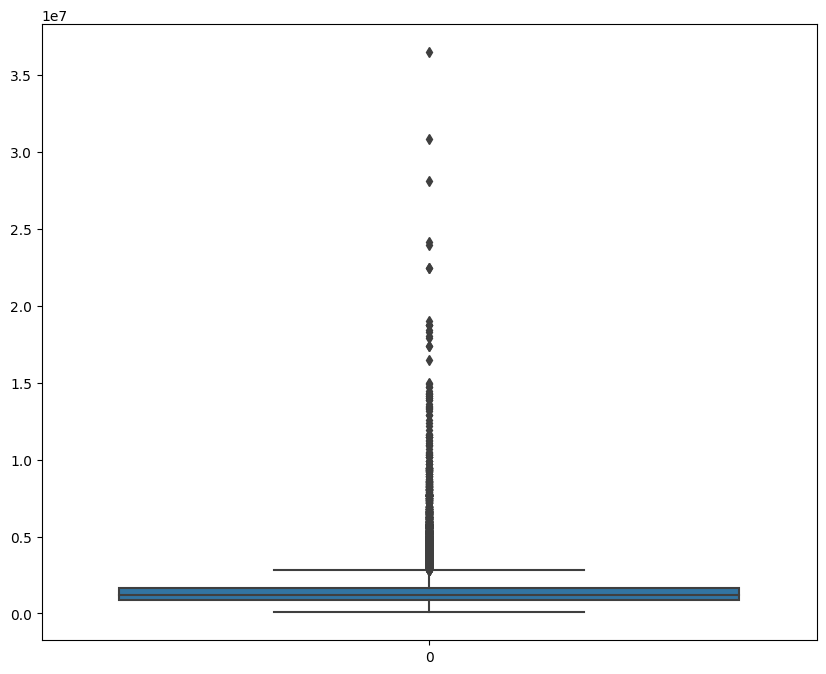

In [21]:
plt.figure(figsize = (10,8))
sns.boxplot(df["Annual Income"]);

In [22]:
df["Annual Income"]

0        1167493.0
1              NaN
2        2231892.0
3         806949.0
4              NaN
           ...    
99995     475437.0
99996    1289416.0
99997    1150545.0
99998    1717524.0
99999     935180.0
Name: Annual Income, Length: 99999, dtype: float64

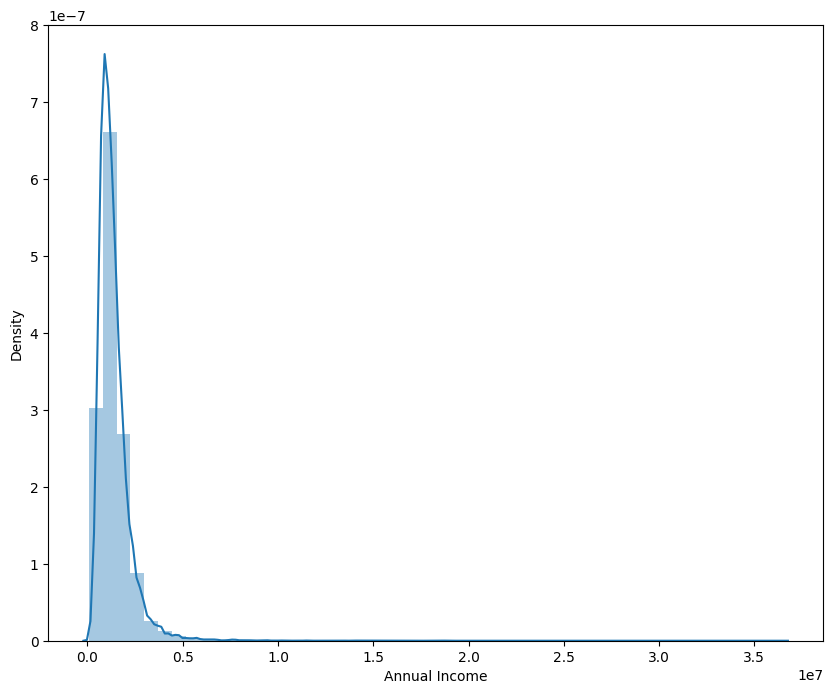

In [23]:
plt.figure(figsize = (10,8))
sns.distplot(df["Annual Income"]);

In [24]:
df["Annual Income"] = df["Annual Income"].fillna(df["Annual Income"].median())

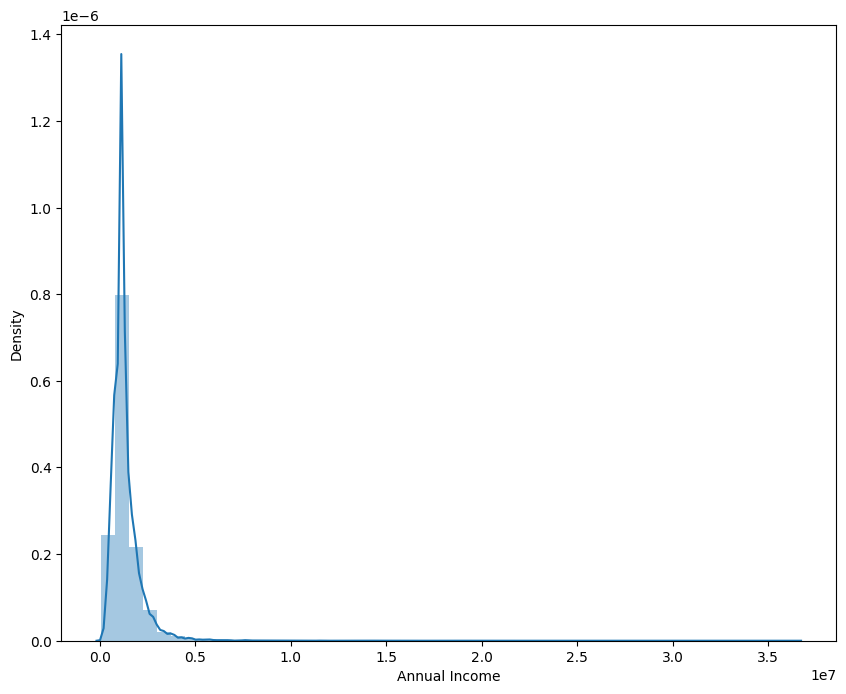

In [25]:
plt.figure(figsize = (10,8))
sns.distplot(df["Annual Income"]);

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99999 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan ID                       99999 non-null  object 
 1   Customer ID                   99999 non-null  object 
 2   Loan Status                   99999 non-null  object 
 3   Current Loan Amount           99999 non-null  float64
 4   Term                          99999 non-null  object 
 5   Credit Score                  99999 non-null  float64
 6   Annual Income                 99999 non-null  float64
 7   Years in current job          95777 non-null  object 
 8   Home Ownership                99999 non-null  object 
 9   Purpose                       99999 non-null  object 
 10  Monthly Debt                  99999 non-null  float64
 11  Years of Credit History       99999 non-null  float64
 12  Months since last delinquent  46859 non-null  float64
 13  N

In [27]:
df["Years in current job"].unique()

array(['8 years', '10+ years', '3 years', '5 years', '< 1 year',
       '2 years', '4 years', '9 years', '7 years', '1 year', nan,
       '6 years'], dtype=object)

In [28]:
# convert to float values

df["Years in current job"] = df["Years in current job"].str.extract('(\d+)').astype(float)
df["Years in current job"]

0         8.0
1        10.0
2         8.0
3         3.0
4         5.0
         ... 
99995     7.0
99996     1.0
99997     6.0
99998     9.0
99999     NaN
Name: Years in current job, Length: 99999, dtype: float64

In [29]:
df["Years in current job"].describe()

count    95777.000000
mean         5.977552
std          3.501103
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max         10.000000
Name: Years in current job, dtype: float64

In [30]:
df["Years in current job"] = df["Years in current job"].fillna(0)
df["Years in current job"]

0         8.0
1        10.0
2         8.0
3         3.0
4         5.0
         ... 
99995     7.0
99996     1.0
99997     6.0
99998     9.0
99999     0.0
Name: Years in current job, Length: 99999, dtype: float64

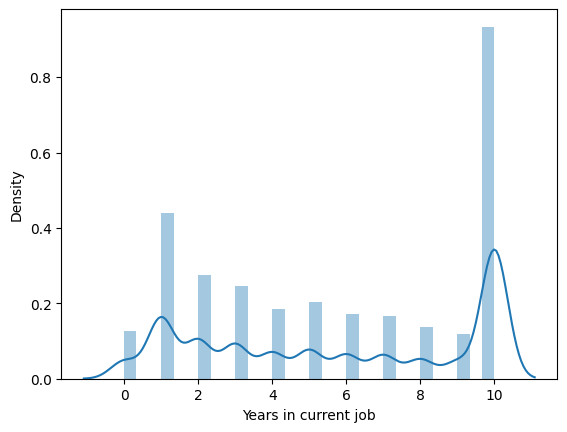

In [31]:
sns.distplot(df["Years in current job"]);

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99999 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan ID                       99999 non-null  object 
 1   Customer ID                   99999 non-null  object 
 2   Loan Status                   99999 non-null  object 
 3   Current Loan Amount           99999 non-null  float64
 4   Term                          99999 non-null  object 
 5   Credit Score                  99999 non-null  float64
 6   Annual Income                 99999 non-null  float64
 7   Years in current job          99999 non-null  float64
 8   Home Ownership                99999 non-null  object 
 9   Purpose                       99999 non-null  object 
 10  Monthly Debt                  99999 non-null  float64
 11  Years of Credit History       99999 non-null  float64
 12  Months since last delinquent  46859 non-null  float64
 13  N

In [33]:
df["Months since last delinquent"].describe()

count    46859.000000
mean        34.901321
std         21.997829
min          0.000000
25%         16.000000
50%         32.000000
75%         51.000000
max        176.000000
Name: Months since last delinquent, dtype: float64

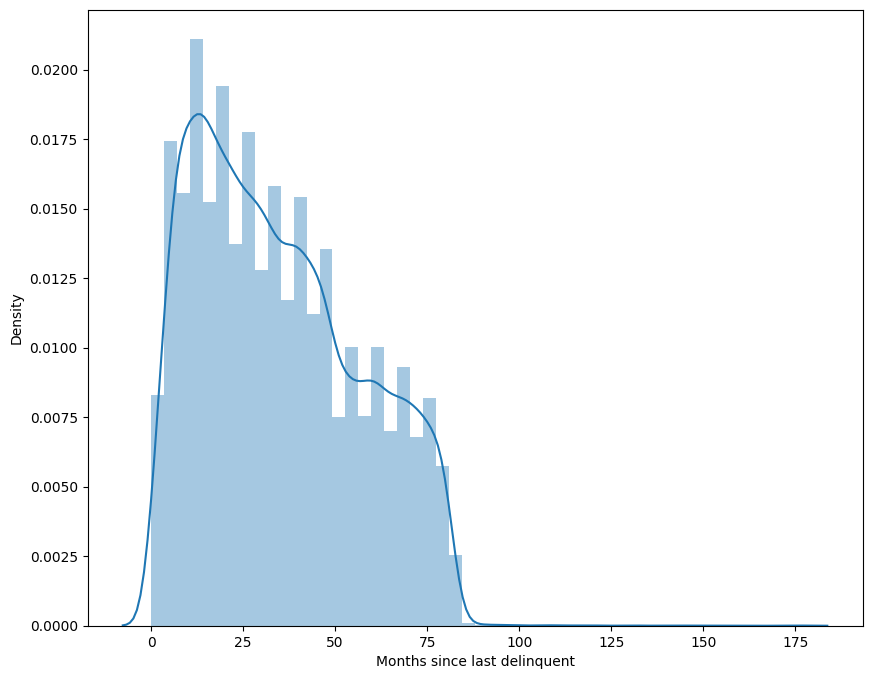

In [34]:
plt.figure(figsize = (10,8))
sns.distplot(df["Months since last delinquent"]);

In [35]:
# drop variable because there are lots of missing value

df = df.drop("Months since last delinquent", axis = 1)
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8.0,Home Mortgage,Home Improvements,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,724.0,1174143.0,10.0,Home Mortgage,Debt Consolidation,33295.98,21.1,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8.0,Own Home,Debt Consolidation,29200.53,14.9,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3.0,Own Home,Debt Consolidation,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,724.0,1174143.0,5.0,Rent,Debt Consolidation,20639.70,6.1,15.0,0.0,253460.0,427174.0,0.0,0.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99999 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Loan ID                    99999 non-null  object 
 1   Customer ID                99999 non-null  object 
 2   Loan Status                99999 non-null  object 
 3   Current Loan Amount        99999 non-null  float64
 4   Term                       99999 non-null  object 
 5   Credit Score               99999 non-null  float64
 6   Annual Income              99999 non-null  float64
 7   Years in current job       99999 non-null  float64
 8   Home Ownership             99999 non-null  object 
 9   Purpose                    99999 non-null  object 
 10  Monthly Debt               99999 non-null  float64
 11  Years of Credit History    99999 non-null  float64
 12  Number of Open Accounts    99999 non-null  float64
 13  Number of Credit Problems  99999 non-null  flo

In [37]:
df.dropna(subset = ["Maximum Open Credit","Bankruptcies","Tax Liens"], inplace = True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99793 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Loan ID                    99793 non-null  object 
 1   Customer ID                99793 non-null  object 
 2   Loan Status                99793 non-null  object 
 3   Current Loan Amount        99793 non-null  float64
 4   Term                       99793 non-null  object 
 5   Credit Score               99793 non-null  float64
 6   Annual Income              99793 non-null  float64
 7   Years in current job       99793 non-null  float64
 8   Home Ownership             99793 non-null  object 
 9   Purpose                    99793 non-null  object 
 10  Monthly Debt               99793 non-null  float64
 11  Years of Credit History    99793 non-null  float64
 12  Number of Open Accounts    99793 non-null  float64
 13  Number of Credit Problems  99793 non-null  flo

In [39]:
df.drop(["Loan ID", "Customer ID"], axis = 1, inplace = True)
df.head()

,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,Fully Paid,445412.0,Short Term,709.0,1167493.0,8.0,Home Mortgage,Home Improvements,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0,0.0
1,Fully Paid,262328.0,Short Term,724.0,1174143.0,10.0,Home Mortgage,Debt Consolidation,33295.98,21.1,35.0,0.0,229976.0,850784.0,0.0,0.0
2,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8.0,Own Home,Debt Consolidation,29200.53,14.9,18.0,1.0,297996.0,750090.0,0.0,0.0
3,Fully Paid,347666.0,Long Term,721.0,806949.0,3.0,Own Home,Debt Consolidation,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0,0.0
4,Fully Paid,176220.0,Short Term,724.0,1174143.0,5.0,Rent,Debt Consolidation,20639.70,6.1,15.0,0.0,253460.0,427174.0,0.0,0.0


# Resolving imbalance problem

In [40]:
from sklearn.utils import resample

In [41]:
df["Loan Status"].value_counts()

Fully Paid     77207
Charged Off    22586
Name: Loan Status, dtype: int64

In [42]:
df_majority = df[df["Loan Status"] == "Fully Paid"]
df_minority = df[df["Loan Status"] == "Charged Off"]

In [43]:
df_minority_upsampled = resample(df_minority, 
                                 replace=True,     # sample with replacement
                                 n_samples=77207,    # to match majority class
                                 random_state=123) # reproducible results

In [44]:
df_minority_upsampled

,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
88478,Charged Off,99748.0,Short Term,676.0,426113.0,0.0,Rent,Other,2570.89,28.5,6.0,0.0,81928.0,353958.0,0.0,0.0
70013,Charged Off,277860.0,Short Term,7340.0,1127498.0,8.0,Rent,Debt Consolidation,22643.82,11.2,12.0,1.0,214833.0,346456.0,0.0,1.0
78865,Charged Off,746482.0,Long Term,701.0,1401706.0,10.0,Rent,Debt Consolidation,26632.30,23.4,15.0,0.0,645430.0,1237324.0,0.0,0.0
95594,Charged Off,248468.0,Short Term,7090.0,634429.0,10.0,Rent,Debt Consolidation,9728.00,11.6,11.0,0.0,376295.0,453860.0,0.0,0.0
68428,Charged Off,781396.0,Short Term,724.0,1174143.0,10.0,Home Mortgage,Business Loan,36674.37,23.4,13.0,0.0,670719.0,836880.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21843,Charged Off,326480.0,Short Term,733.0,1691703.0,6.0,Rent,Debt Consolidation,12955.72,13.5,7.0,2.0,123728.0,406978.0,2.0,0.0
85695,Charged Off,257532.0,Short Term,740.0,1056476.0,10.0,Rent,Debt Consolidation,12237.33,15.3,5.0,0.0,153387.0,315480.0,0.0,0.0
56945,Charged Off,336314.0,Long Term,724.0,1174143.0,1.0,Rent,Debt Consolidation,5467.63,10.0,16.0,0.0,205694.0,401632.0,0.0,0.0
51482,Charged Off,264396.0,Long Term,713.0,1560337.0,10.0,Home Mortgage,Debt Consolidation,29776.42,18.6,17.0,0.0,366947.0,643764.0,0.0,0.0


In [45]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [46]:
df_upsampled["Loan Status"].value_counts()

Fully Paid     77207
Charged Off    77207
Name: Loan Status, dtype: int64

# Feature Engineering

In [47]:
df_upsampled.select_dtypes("object").apply(lambda x: x.unique())

Loan Status                               [Fully Paid, Charged Off]
Term                                        [Short Term, Long Term]
Home Ownership        [Home Mortgage, Own Home, Rent, HaveMortgage]
Purpose           [Home Improvements, Debt Consolidation, Buy Ho...
dtype: object

In [48]:
df_upsampled["Purpose"].unique()

array(['Home Improvements', 'Debt Consolidation', 'Buy House', 'other',
       'Business Loan', 'Buy a Car', 'Take a Trip', 'Other',
       'Medical Bills', 'wedding', 'vacation', 'major_purchase',
       'small_business', 'Educational Expenses', 'moving',
       'renewable_energy'], dtype=object)

In [49]:
df_upsampled["Loan Status"] = df_upsampled["Loan Status"].replace({"Fully Paid" : 1, "Charged Off" : 0})

In [50]:
df_upsampled.head()

,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,1,445412.0,Short Term,709.0,1167493.0,8.0,Home Mortgage,Home Improvements,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0,0.0
1,1,262328.0,Short Term,724.0,1174143.0,10.0,Home Mortgage,Debt Consolidation,33295.98,21.1,35.0,0.0,229976.0,850784.0,0.0,0.0
2,1,99999999.0,Short Term,741.0,2231892.0,8.0,Own Home,Debt Consolidation,29200.53,14.9,18.0,1.0,297996.0,750090.0,0.0,0.0
3,1,347666.0,Long Term,721.0,806949.0,3.0,Own Home,Debt Consolidation,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0,0.0
4,1,176220.0,Short Term,724.0,1174143.0,5.0,Rent,Debt Consolidation,20639.70,6.1,15.0,0.0,253460.0,427174.0,0.0,0.0


In [51]:
df_upsampled.head()

,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,1,445412.0,Short Term,709.0,1167493.0,8.0,Home Mortgage,Home Improvements,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0,0.0
1,1,262328.0,Short Term,724.0,1174143.0,10.0,Home Mortgage,Debt Consolidation,33295.98,21.1,35.0,0.0,229976.0,850784.0,0.0,0.0
2,1,99999999.0,Short Term,741.0,2231892.0,8.0,Own Home,Debt Consolidation,29200.53,14.9,18.0,1.0,297996.0,750090.0,0.0,0.0
3,1,347666.0,Long Term,721.0,806949.0,3.0,Own Home,Debt Consolidation,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0,0.0
4,1,176220.0,Short Term,724.0,1174143.0,5.0,Rent,Debt Consolidation,20639.70,6.1,15.0,0.0,253460.0,427174.0,0.0,0.0


In [52]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [53]:
X = df_upsampled.drop("Loan Status", axis = 1)
y = df_upsampled["Loan Status"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [55]:
X_train.shape

(123531, 15)

In [56]:
X_test.shape

(30883, 15)

In [57]:
X_train.head()

,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
40844,99999999.0,Short Term,741.0,462707.0,2.0,Home Mortgage,Medical Bills,4627.07,21.4,3.0,0.0,0.0,0.0,0.0,0.0
17248,263362.0,Long Term,663.0,1516352.0,10.0,Own Home,Debt Consolidation,23124.33,26.0,17.0,0.0,534603.0,723998.0,0.0,0.0
45557,68420.0,Short Term,724.0,1174143.0,10.0,Own Home,Debt Consolidation,19396.34,13.9,8.0,0.0,147231.0,469656.0,0.0,0.0
75386,294514.0,Long Term,724.0,1174143.0,10.0,Home Mortgage,Debt Consolidation,19983.44,16.2,10.0,0.0,56696.0,261514.0,0.0,0.0
1826,44660.0,Short Term,715.0,867749.0,1.0,Rent,other,7672.39,11.0,5.0,0.0,16986.0,22330.0,0.0,0.0


## Preprocessing

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer

In [59]:
def map_func(x):
    return x.str.extract('(\d+)').astype(float)


class SelectColumnsTransformer():
    def __init__(self, columns=None):
        self.columns = columns

    def transform(self, X, **transform_params):
        X_scaled = X.copy()
        X_scaled[self.columns] = map_func(X_scaled[self.columns])
        return X_scaled
    
    def fit(self, X, y=None, **fit_params):
        return self    
  

In [60]:
def minmax(y):
    return MinMaxScaler().fit_transform(y)


class Minmaxscaler():
    def __init__(self, columns=None):
        self.columns = columns

    def transform(self, X_scaled, **transform_params):
        X_scaled[self.columns] = minmax(X_scaled[self.columns])
        return X_scaled
    
    def fit(self, X_scaled, y=None, **fit_params):
        return self
        

In [61]:
def label(z):
    return z.apply(lambda x: LabelEncoder().fit_transform(x))


class Labelencoder():
    def __init__(self, columns=None):
        self.columns = columns

    def transform(self, X_scaled, **transform_params):
        X_scaled[self.columns] = label(X_scaled[self.columns])
        return X_scaled
    
    def fit(self, X_scaled, y=None, **fit_params):
        return self  
        

In [62]:
# Using Pipeline to get scaling and modelling

from sklearn.preprocessing import OneHotEncoder

num_features = list(X_train.select_dtypes(exclude="object"))
num_transformer = Pipeline([("scaler", MinMaxScaler())])

cat_features = list(X_train.select_dtypes(include="object"))
cat_transformer = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessing = ColumnTransformer([("first", num_transformer, num_features),
          ("second", cat_transformer, cat_features)
          ])

In [63]:
def model_test(model_name): # test model performance for default parameters
    pipeline = Pipeline([("preprocessing", preprocessing),
               ("model", model_name)])
    
    global model_fitted
    model_fitted = pipeline.fit(X_train, y_train)
    train_pred = model_fitted.predict(X_train)
    test_pred = model_fitted.predict(X_test)
    print("Train_set Accuracy: %.2f" % accuracy_score(y_train, train_pred))
    print("-----------------------------------------")
    print("Test_set Accuracy: %.2f" % accuracy_score(y_test, test_pred))
    print("-----------------------------------------")
    print("Test_set Confusion Matrix: \n", confusion_matrix(y_test, test_pred))
    print("-----------------------------------------")
    print("Test_report: \n", classification_report(y_test, test_pred))

In [64]:
def parameter_search(model_name,model_params): # searching best parameter of models
    pipeline = Pipeline([("preprocessing", preprocessing),
               ("model", model_name)])
    
    best_params = GridSearchCV(pipeline, model_params, 
                               cv = 10, scoring = "accuracy").fit(X_train, y_train).best_params_
    return best_params

In [65]:
def optimization(model_name, params): # model test and scoring metrics with hyperparameters   
    pipeline = Pipeline([("preprocessing", preprocessing),
               ("model", model_name)])
    global model_tuned
    model_tuned = pipeline.set_params(**params).fit(X_train, y_train)
    train_pred = model_tuned.predict(X_train)
    test_pred = model_tuned.predict(X_test)
    print("Tuned Model Evaluating")
    print("=========================================")
    print("=========================================\n")
    print("Train_set Accuracy: %.2f" % accuracy_score(y_train, train_pred))
    print("-----------------------------------------")
    print("Test_set Accuracy: %.2f" % accuracy_score(y_test, test_pred))
    print("-----------------------------------------")
    print("Test_set Confusion Matrix: \n", confusion_matrix(y_test, test_pred))
    print("-----------------------------------------")
    print("Test_report: \n", classification_report(y_test, test_pred))
    print("-----------------------------------------")
    print("Test_curve: \n")
    
    model_roc_auc = roc_auc_score(y_test, test_pred)

    fpr, tpr, thresholds = roc_curve(y_test, model_tuned.predict_proba(X_test)[:,1])
    plt.figure(figsize = (7,5))
    plt.plot(fpr, tpr, label = "AUC (area = %0.2f)" % model_roc_auc)
    plt.plot([0, 1], [0, 1],"r--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive", fontsize = 12, fontweight = "bold")
    plt.ylabel("True Positive", fontsize = 12, fontweight = "bold")
    plt.title("Tuned Model ROC Curve", fontsize = 11, fontweight = "bold", color = "brown")
    plt.show()
    
    return model_tuned

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model_test(LogisticRegression(max_iter = 1000))

In [ ]:
log_params = {"model__C" : [0.1,1,5],
             "model__solver" : ["lbfgs", "liblinear", "sag"]}

In [ ]:
#log_best_params = parameter_search(LogisticRegression(max_iter = 1000),log_params)
#log_best_params
log_best_params = {'model__C': 1, 'model__solver': 'lbfgs'}

In [ ]:
log_tuned = optimization(LogisticRegression(),log_best_params)
log_tuned

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
model_test(KNeighborsClassifier())

In [ ]:
knn_params = {"model__n_neighbors" : [5,10,15,20]}

In [ ]:
#knn_best_params = parameter_search(KNeighborsClassifier(), knn_params)
#knn_best_params
knn_best_params = {'model__n_neighbors': 5}

In [ ]:
knn_tuned = optimization(KNeighborsClassifier(), knn_best_params)
knn_tuned

# Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
model_test(RandomForestClassifier())

Train_set Accuracy: 1.00
-----------------------------------------
Test_set Accuracy: 0.96
-----------------------------------------
Test_set Confusion Matrix: 
 [[14788   703]
 [  649 14743]]
-----------------------------------------
Test_report: 
               precision    recall  f1-score   support

           0       0.96      0.95      0.96     15491
           1       0.95      0.96      0.96     15392

    accuracy                           0.96     30883
   macro avg       0.96      0.96      0.96     30883
weighted avg       0.96      0.96      0.96     30883



In [78]:
rf_params = {"model__n_estimators" : [100,500,750],
            "model__max_depth" : [50,100]}

In [79]:
#rf_best_params = parameter_search(RandomForestClassifier(), rf_params)
#rf_best_params
rf_best_params = {'model__max_depth': 100, 'model__n_estimators': 750}

Tuned Model Evaluating

Train_set Accuracy: 1.00
-----------------------------------------
Test_set Accuracy: 0.96
-----------------------------------------
Test_set Confusion Matrix: 
 [[14761   730]
 [  517 14875]]
-----------------------------------------
Test_report: 
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     15491
           1       0.95      0.97      0.96     15392

    accuracy                           0.96     30883
   macro avg       0.96      0.96      0.96     30883
weighted avg       0.96      0.96      0.96     30883

-----------------------------------------
Test_curve: 



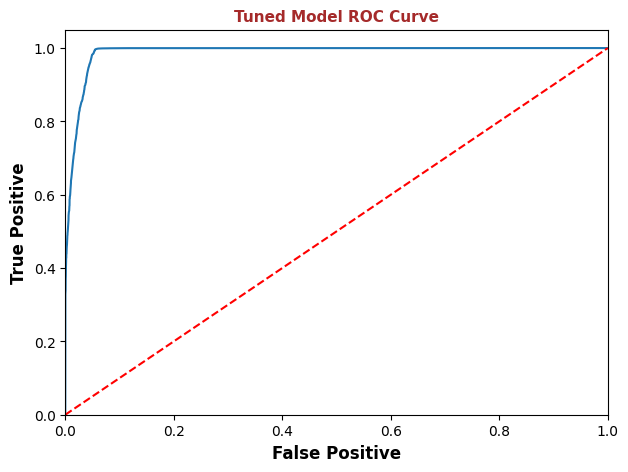

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('first',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Current Loan Amount',
                                                   'Credit Score',
                                                   'Annual Income',
                                                   'Years in current job',
                                                   'Monthly Debt',
                                                   'Years of Credit History',
                                                   'Number of Open Accounts',
                                                   'Number of Credit Problems',
                                                   'Current Credit Balance',
                                                   'Maximum Open Credit',
                                                   'Bankruptcies',
                                                   'Tax Liens']),
                                                 ('second',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Term', 'Home Ownership',
                                                   'Purpose'])])),
                ('model',
                 RandomForestClassifier(max_depth=100, n_estimators=750))])

In [80]:
rf_tuned = optimization(RandomForestClassifier(), rf_best_params)
rf_tuned

In [81]:
# model save

from joblib import dump
dump(rf_tuned, "rf_bank_model_final.pkl")

['rf_bank_model_final.pkl']

# XGBoost Classifier

In [66]:
from xgboost import XGBClassifier

In [67]:
model_test(XGBClassifier())

Train_set Accuracy: 0.77
-----------------------------------------
Test_set Accuracy: 0.74
-----------------------------------------
Test_set Confusion Matrix: 
 [[11411  4080]
 [ 3889 11503]]
-----------------------------------------
Test_report: 
               precision    recall  f1-score   support

           0       0.75      0.74      0.74     15491
           1       0.74      0.75      0.74     15392

    accuracy                           0.74     30883
   macro avg       0.74      0.74      0.74     30883
weighted avg       0.74      0.74      0.74     30883



In [73]:
xgb_params = {"model__n_estimators": [100, 500],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.1,0.01]}

In [74]:
#xgb_best_params = parameter_search(XGBClassifier(), xgb_params)
#xgb_best_params
xgb_best_params = {'model__learning_rate': 0.1,
 'model__max_depth': 5,
 'model__n_estimators': 500,
 'model__subsample': 0.6}

Tuned Model Evaluating

Train_set Accuracy: 0.79
-----------------------------------------
Test_set Accuracy: 0.76
-----------------------------------------
Test_set Confusion Matrix: 
 [[11562  3929]
 [ 3624 11768]]
-----------------------------------------
Test_report: 
               precision    recall  f1-score   support

           0       0.76      0.75      0.75     15491
           1       0.75      0.76      0.76     15392

    accuracy                           0.76     30883
   macro avg       0.76      0.76      0.76     30883
weighted avg       0.76      0.76      0.76     30883

-----------------------------------------
Test_curve: 



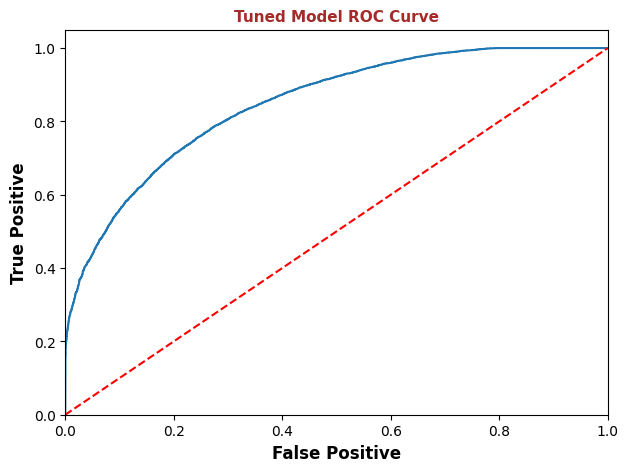

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('first',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Current Loan Amount',
                                                   'Credit Score',
                                                   'Annual Income',
                                                   'Years in current job',
                                                   'Monthly Debt',
                                                   'Years of Credit History',
                                                   'Number of Open Accounts',
                                                   'Number of Credit Problems',
                                                   'Current Credit Balance',
                                                   'Maximum Open Credit',
                                                   'Bankruptcies',
                                                   'Tax Liens']),
                                                 ('seco...
                               feature_types=None, gamma=None, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, n_estimators=500,
                               n_jobs=None, num_parallel_tree=None,
                               predictor=None, random_state=None, ...))])

In [75]:
xgb_tuned = optimization(XGBClassifier(), xgb_best_params)
xgb_tuned

In [ ]:
# model save

from joblib import dump
dump(rf_tuned, "rf_bank_model.pkl")

In [82]:
# model save

from joblib import dump
dump(xgb_tuned, "xgb_bank_model.pkl")

['xgb_bank_model.pkl']